In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv
import warnings
import os

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

DB = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB)

comp = pd.read_sql("SELECT * FROM dim_company", engine)
pl   = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs   = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)

for col in ['sales', 'net_profit', 'opm_pct', 'operating_profit']:
    pl[col] = pd.to_numeric(pl[col], errors='coerce')
for col in ['borrowings']:
    bs[col] = pd.to_numeric(bs[col], errors='coerce')

pl = pl.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')

print(f"✅ Real data loaded — {comp.shape[0]} companies!")

✅ Real data loaded — 94 companies!


In [16]:
# Step 1 — Z-score detection on key metrics
metrics_to_check = ['sales', 'net_profit', 'opm_pct', 'operating_profit']

pl_merged = pl.copy()

anomaly_flags = []

for col in metrics_to_check:
    temp = pl_merged[['company_id', 'company_name', 'sector', 'year_id', col]].copy()
    temp['z_score'] = np.abs(stats.zscore(temp[col].fillna(temp[col].median())))
    temp['metric'] = col
    temp['value'] = temp[col]
    temp['is_anomaly_z'] = temp['z_score'] > 3
    anomaly_flags.append(temp[['company_id', 'company_name', 'sector',
                                'year_id', 'metric', 'value', 'z_score', 'is_anomaly_z']])

z_anomalies = pd.concat(anomaly_flags, ignore_index=True)
z_anomalies_only = z_anomalies[z_anomalies['is_anomaly_z']]

print(f"Total anomalies found (|z| > 3): {len(z_anomalies_only)}")
print(f"\nBy metric:")
print(z_anomalies_only.groupby('metric').size())
print(f"\nTop anomalies:")
display(z_anomalies_only.sort_values('z_score', ascending=False).head(10))

Total anomalies found (|z| > 3): 44

By metric:
metric
operating_profit    20
opm_pct             24
dtype: int64

Top anomalies:


,company_id,company_name,sector,year_id,metric,value,z_score,is_anomaly_z
2466,56,PAYTM,Unknown,2016,opm_pct,-195.0,10.461354,True
2859,2,RELIANCE,Unknown,2025,operating_profit,165598.0,9.591719,True
2858,2,RELIANCE,Unknown,2024,operating_profit,162498.0,9.401717,True
2475,57,POLICYBZR,Unknown,2016,opm_pct,-157.0,8.606571,True
2857,2,RELIANCE,Unknown,2023,operating_profit,142318.0,8.164862,True
2467,56,PAYTM,Unknown,2019,opm_pct,-135.0,7.532749,True
2710,83,PVRINOX,Unknown,2021,opm_pct,-120.0,6.800597,True
2465,56,PAYTM,Unknown,2015,opm_pct,-111.0,6.361307,True
2856,2,RELIANCE,Unknown,2022,operating_profit,108581.0,6.097084,True
3108,25,ONGC,Unknown,2024,operating_profit,102383.0,5.717202,True


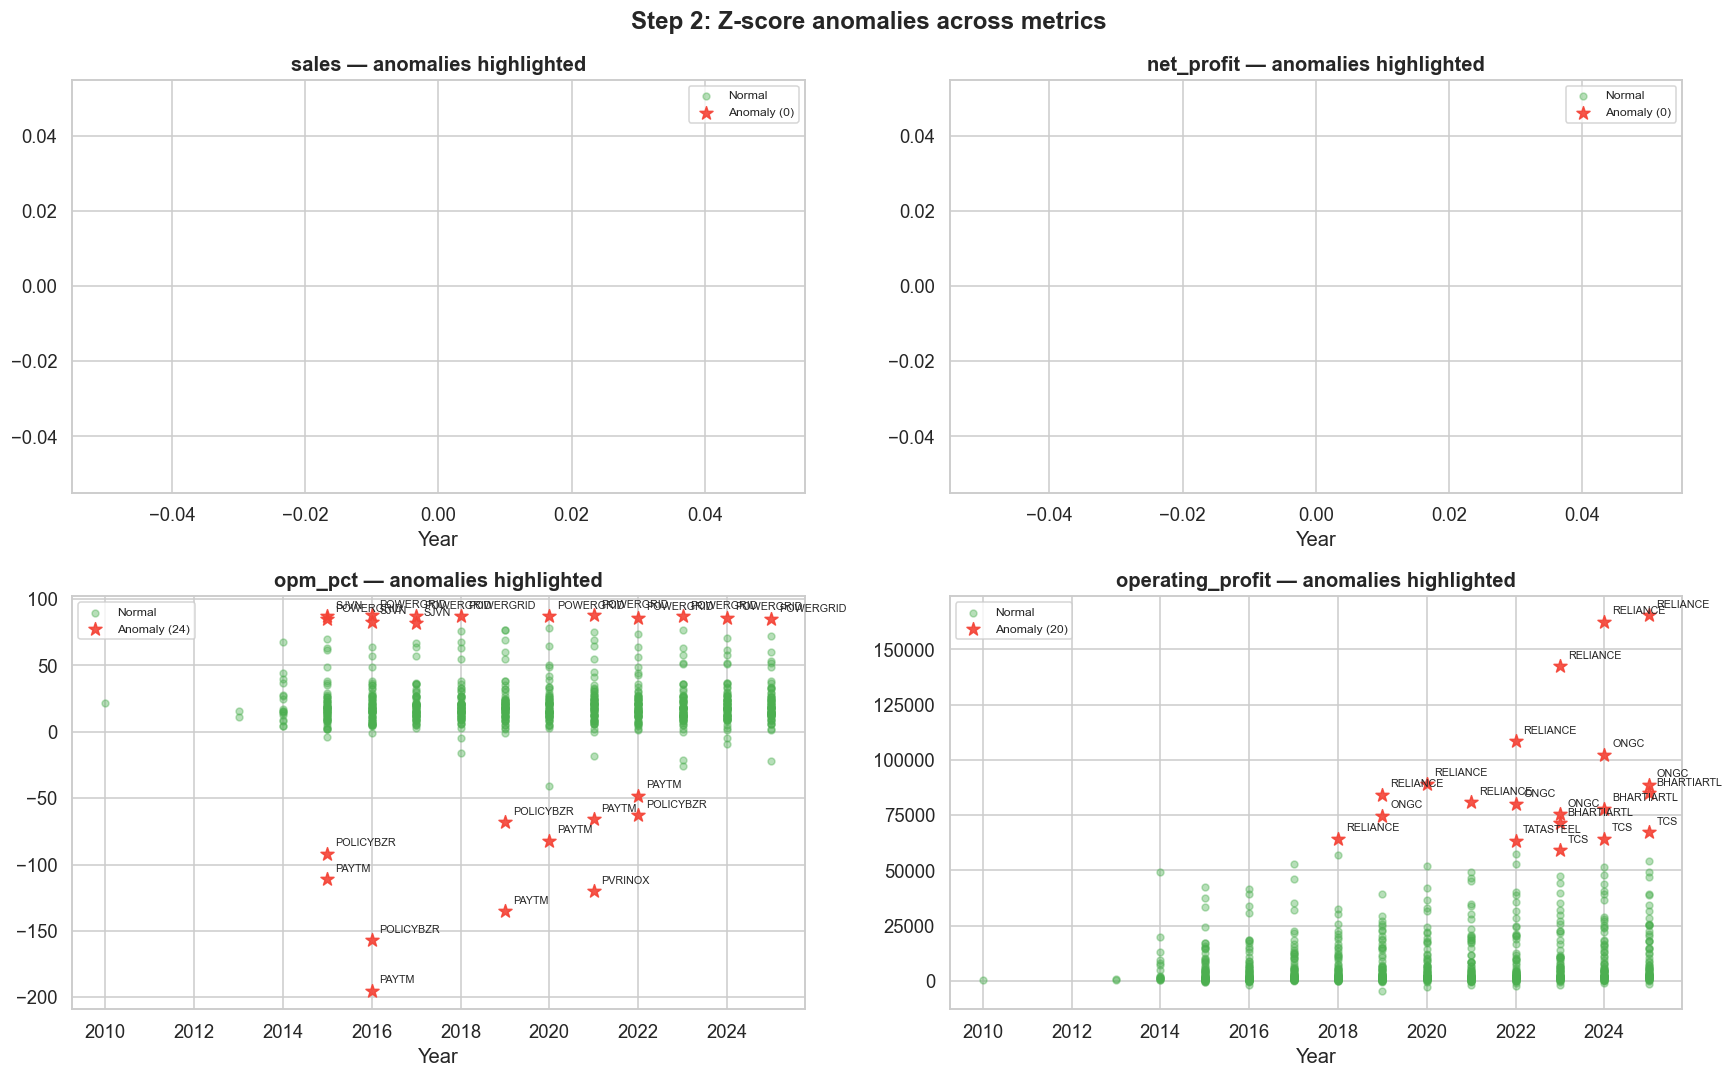

In [17]:
# Step 2 — Visualize anomalies on timeline
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flat, metrics_to_check):
    data = pl_merged[pl_merged['metric'] == col] if 'metric' in pl_merged.columns else pl_merged
    normal = z_anomalies[(z_anomalies['metric'] == col) & (~z_anomalies['is_anomaly_z'])]
    anomal = z_anomalies[(z_anomalies['metric'] == col) & (z_anomalies['is_anomaly_z'])]
    
    ax.scatter(normal['year_id'], normal['value'],
               c='#4CAF50', alpha=0.4, s=20, label='Normal')
    ax.scatter(anomal['year_id'], anomal['value'],
               c='#F44336', alpha=0.9, s=80, marker='*', label=f'Anomaly ({len(anomal)})')
    
    for _, row in anomal.iterrows():
        ax.annotate(row['company_name'],
                    (row['year_id'], row['value']),
                    fontsize=7, ha='left',
                    xytext=(5, 5), textcoords='offset points')
    
    ax.set_title(f'{col} — anomalies highlighted', fontweight='bold')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

plt.suptitle('Step 2: Z-score anomalies across metrics', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Step 3 — Isolation Forest on full feature matrix
feature_cols = ['sales', 'net_profit', 'opm_pct', 'operating_profit']
X = pl[feature_cols].fillna(pl[feature_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.05, random_state=42)
pl['iso_flag'] = iso.fit_predict(X_scaled)
pl['is_anomaly_iso'] = pl['iso_flag'] == -1
print(pl.columns.tolist())    # pl ke columns dekh
print(comp.columns.tolist())  # comp ke columns dekh

pl_iso = pl.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')
print(pl_iso.columns.tolist())  # check karo company_name aaya ya nahi
print(pl_iso.shape)             # rows kitni hain

print(f"Isolation Forest anomalies found: {pl['is_anomaly_iso'].sum()}")
print(f"\nTop anomalous companies:")
display(
    pl_iso[pl_iso['is_anomaly_iso']]
    .groupby('company_id')['is_anomaly_iso']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'is_anomaly_iso': 'anomaly_years'})
)

['id', 'company_id', 'year_id', 'sales', 'net_profit', 'opm_pct', 'operating_profit', 'interest', 'expenses', 'dividend_payout_pct', 'company_name', 'sector', 'iso_flag', 'is_anomaly_iso']
['company_id', 'company_name', 'sector', 'roe_percentage']
['id', 'company_id', 'year_id', 'sales', 'net_profit', 'opm_pct', 'operating_profit', 'interest', 'expenses', 'dividend_payout_pct', 'company_name_x', 'sector_x', 'iso_flag', 'is_anomaly_iso', 'company_name_y', 'sector_y']
(946, 16)
Isolation Forest anomalies found: 48

Top anomalous companies:


,company_id,anomaly_years
0,21,11
1,2,8
2,56,6
3,9,5
4,57,5
5,25,5
6,1,3
7,28,1
8,33,1
9,30,1


Z-score anomalies    : 10 companies
Isolation Forest     : 12 companies
Flagged by BOTH      : 0 companies ← most suspicious!
Only Z-score         : 10 companies
Only Isolation Forest: 12 companies

🚨 Most suspicious (flagged by both):


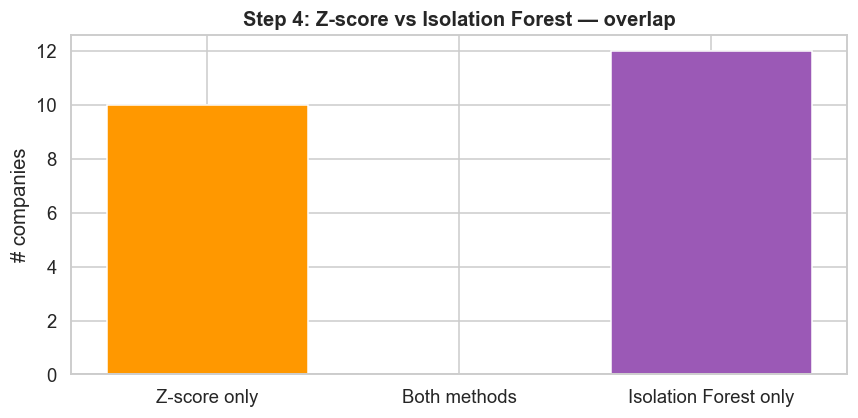

In [19]:
# Step 4 — Compare Z-score vs Isolation Forest
z_companies = set(z_anomalies_only['company_name'].unique())

iso_companies = set(pl_iso[pl_iso['is_anomaly_iso']]['company_id'].unique())

both = z_companies & iso_companies
only_z = z_companies - iso_companies
only_iso = iso_companies - z_companies

print(f"Z-score anomalies    : {len(z_companies)} companies")
print(f"Isolation Forest     : {len(iso_companies)} companies")
print(f"Flagged by BOTH      : {len(both)} companies ← most suspicious!")
print(f"Only Z-score         : {len(only_z)} companies")
print(f"Only Isolation Forest: {len(only_iso)} companies")

print(f"\n🚨 Most suspicious (flagged by both):")
for c in both:
    print(f"   {c}")

# Venn-style bar
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(['Z-score only', 'Both methods', 'Isolation Forest only'],
       [len(only_z), len(both), len(only_iso)],
       color=['#FF9800', '#F44336', '#9B59B6'], edgecolor='white')
ax.set_ylabel('# companies')
ax.set_title('Step 4: Z-score vs Isolation Forest — overlap', fontweight='bold')
plt.tight_layout()
plt.show()

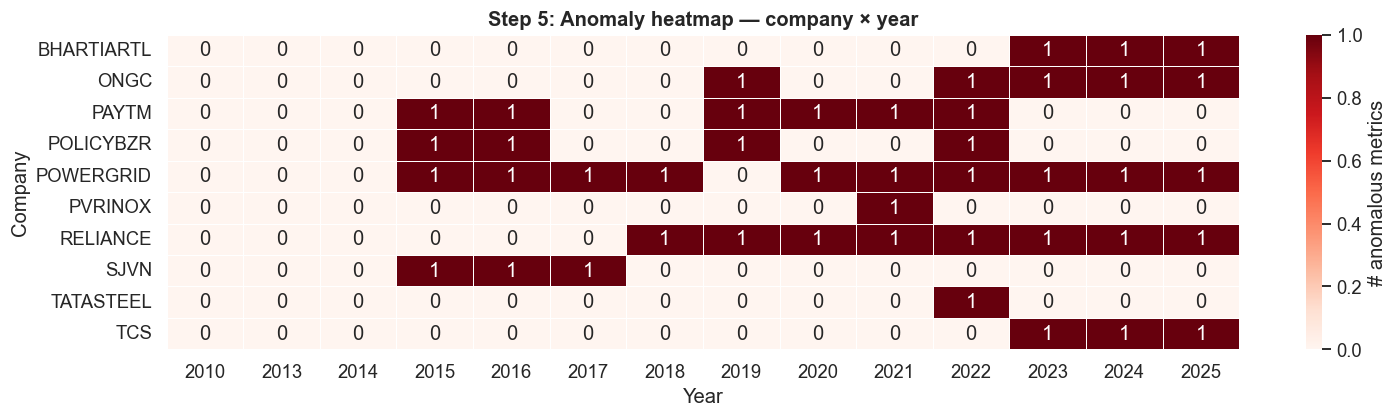

In [20]:
# Step 5 — Which companies had most anomalous years?
anomaly_matrix = z_anomalies.pivot_table(
    index='company_name',
    columns='year_id',
    values='is_anomaly_z',
    aggfunc='sum',
    fill_value=0
)

# Only show companies with at least 1 anomaly
anomaly_matrix = anomaly_matrix[anomaly_matrix.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(14, max(4, len(anomaly_matrix) * 0.4)))
sns.heatmap(anomaly_matrix, cmap='Reds', linewidths=0.5,
            cbar_kws={'label': '# anomalous metrics'},
            ax=ax, annot=True, fmt='.0f')
ax.set_title('Step 5: Anomaly heatmap — company × year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Company')
plt.tight_layout()
plt.show()

In [21]:
# Step 6 — Export to CSV
os.makedirs('../data/processed', exist_ok=True)

export = z_anomalies_only[['company_id', 'company_name', 'sector',
                             'year_id', 'metric', 'value', 'z_score']].copy()
export['detection_method'] = 'z_score'



# Nayi line - company_name aur sector hata do:
iso_export = pl_iso[pl_iso['is_anomaly_iso']][
    ['company_id', 'year_id']
].copy()
iso_export['metric'] = 'multi_metric'
iso_export['value'] = np.nan
iso_export['z_score'] = np.nan
iso_export['detection_method'] = 'isolation_forest'

final_export = pd.concat([export, iso_export], ignore_index=True)
final_export.to_csv('../data/processed/anomaly_flags.csv', index=False)

print(f"✅ Exported {len(final_export)} anomaly records")
print("   Saved to data/processed/anomaly_flags.csv")

✅ Exported 92 anomaly records
   Saved to data/processed/anomaly_flags.csv


In [22]:
# Notebook 3 Summary
print("="*60)
print("NOTEBOOK 3 SUMMARY — Anomaly Detection")
print("="*60)
print(f"\n🔍 Z-score anomalies    : {len(z_anomalies_only)}")
print(f"🌲 Isolation Forest     : {pl['is_anomaly_iso'].sum()}")
print(f"🚨 Flagged by both      : {len(both)} companies")
print(f"\n✅ Ready for Notebook 4 — Sector Clustering!")

NOTEBOOK 3 SUMMARY — Anomaly Detection

🔍 Z-score anomalies    : 44
🌲 Isolation Forest     : 48
🚨 Flagged by both      : 0 companies

✅ Ready for Notebook 4 — Sector Clustering!
